# OTT 이탈 예측 모델링
## is_repurchase 예측 (1=잔존, 0=이탈)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

# ── 데이터 로드 ──────────────────────────────────────────
mem     = pd.read_csv('Membership_v2.csv')
view    = pd.read_csv('View_History_v2.csv')
movie   = pd.read_csv('Movie_Master_v2.csv')
mapping = pd.read_csv('User_Mapping_v2.csv')

view['view_date'] = pd.to_datetime(view['watch_day'].astype(str), format='%Y%m%d')
mem['reg_date']   = pd.to_datetime(mem['reg_date'])
mem['end_date']   = pd.to_datetime(mem['end_date'])

view_m  = pd.merge(view, movie, on='MOVIE_NUM', how='left')
mem_map = pd.merge(mem, mapping, on='USER_KEY', how='inner')
mem_map = (mem_map
           .sort_values('reg_date', ascending=False)
           .drop_duplicates('USER_KEY')
           .reset_index(drop=True))

print('mem_map:', mem_map.shape)
print('view_m :', view_m.shape)

mem_map: (23134, 16)
view_m : (223744, 9)


In [35]:
# ── 파생변수 생성 (eda_03 동일) ──────────────────────────
latest_date = view_m['view_date'].max()

def agg_view(g):
    dates    = g['view_date'].sort_values()
    gaps     = dates.diff().dt.days.dropna()
    weekdays = dates.dt.dayofweek
    return pd.Series({
        'view_count':        len(g),
        'total_watch_time':  g['watch_time(min)'].sum(),
        'avg_watch_time':    g['watch_time(min)'].mean(),
        'view_days':         dates.dt.date.nunique(),
        'days_since_last':   (latest_date - dates.max()).days,
        'view_regularity':   gaps.std() if len(gaps) > 1 else 0,
        'binge_ratio':       (g['watch_seq'] > 1).mean(),
        'recent_7d_time':    g[g['view_date'] >= latest_date - pd.Timedelta(days=7)]['watch_time(min)'].sum(),
        'weekend_ratio':     (weekdays >= 5).mean(),
        'genre_diversity':   g['genre'].nunique(),
        'top_genre':         g['genre'].mode()[0] if len(g) > 0 else 'Unknown',
        'new_content_ratio': (g['ott_release_month'] >= 202001).mean(),
    })

view_agg = view_m.groupby('USER_NUM').apply(agg_view).reset_index()

# membership 파생변수
mem_map['reg_weekday']   = mem_map['reg_date'].dt.dayofweek
mem_map['reg_time_slot'] = pd.cut(mem_map['reg_hour'],
                                   bins=[-1, 5, 11, 17, 23],
                                   labels=['심야', '오전', '오후', '저녁'])

# 병합
df = pd.merge(mem_map, view_agg, on='USER_NUM', how='left')

view_cols = ['view_count','total_watch_time','avg_watch_time','view_days',
             'recent_7d_time','binge_ratio','weekend_ratio','genre_diversity','new_content_ratio']
df[view_cols]         = df[view_cols].fillna(0)
df['view_regularity'] = df['view_regularity'].fillna(0)
df['days_since_last'] = df['days_since_last'].fillna(999)  # 시청이력 없으면 999
df['top_genre']       = df['top_genre'].fillna('없음')

# 결합 파생변수
df['watch_per_day']           = df.apply(lambda r: r['view_count']/r['view_days'] if r['view_days']>0 else 0, axis=1)
df['is_heavy_user']           = (df['total_watch_time'] >= df['total_watch_time'].quantile(0.8)).astype(int)

# 교호작용 1차
df['binge_intensity']         = df['binge_ratio'] * df['avg_watch_time']
df['diversity_engagement']    = df['genre_diversity'] * df['view_count']
df['heavy_promotion']         = df['is_heavy_user'] * df['is_promotion']
df['churn_promotion']         = df['is_churn_prevented'] * df['is_promotion']
df['recent_engagement_ratio'] = df['recent_7d_time'] / (df['total_watch_time'] + 1)
df['age_promotion']           = df['age'] * df['is_promotion']

# 교호작용 2차
df['price_engagement']        = df['price'] * df['view_count']
df['age_regularity']          = df['age'] * (1 / (df['view_regularity'] + 1))
df['fresh_content_engage']    = df['new_content_ratio'] * df['view_count']
df['plan_genre']              = df['max_screen'] * df['genre_diversity']
df['weekend_binge']           = df['weekend_ratio'] * df['binge_ratio']
df['age_plan']                = df['age'] * df['max_screen']
df['verified_promotion']      = df['is_user_verified'] * df['is_promotion']

print(f'최종 데이터: {df.shape}')
print(f'is_repurchase 분포:\n{df["is_repurchase"].value_counts()}')

최종 데이터: (23134, 45)
is_repurchase 분포:
is_repurchase
1    16563
0     6571
Name: count, dtype: int64


In [36]:
# ── 피처 선택 & 전처리 ──────────────────────────────────
# 범주형 → 인코딩
le_top_genre = LabelEncoder()
le_payment   = LabelEncoder()
le_reg_time  = LabelEncoder()
le_gender    = LabelEncoder()

df['top_genre_enc'] = le_top_genre.fit_transform(df['top_genre'].astype(str))
df['payment_enc']   = le_payment.fit_transform(df['payment_device'].astype(str))
df['reg_time_enc']  = le_reg_time.fit_transform(df['reg_time_slot'].astype(str))
df['gender_enc']    = le_gender.fit_transform(df['gender'].astype(str))

# 사용할 피처 목록
features = [
    # 기본 멤버십
    'price', 'max_screen', 'age',
    'reg_weekday', 'reg_hour', 'reg_time_enc',
    'is_churn_prevented', 'is_user_verified', 'is_promotion',
    'payment_enc', 'gender_enc',

    # 시청 행태
    'view_count', 'total_watch_time', 'avg_watch_time', 'view_days',
    'days_since_last', 'view_regularity', 'binge_ratio',
    'recent_7d_time', 'weekend_ratio', 'watch_per_day',
    'genre_diversity', 'new_content_ratio', 'top_genre_enc',
    'is_heavy_user',

    # 교호작용 1차
    'binge_intensity', 'diversity_engagement',
    'heavy_promotion', 'churn_promotion',
    'recent_engagement_ratio', 'age_promotion',

    # 교호작용 2차
    'price_engagement', 'age_regularity',
    'fresh_content_engage', 'plan_genre', 'weekend_binge',
    'age_plan', 'verified_promotion',
]

X = df[features].copy()
y = df['is_repurchase'].copy()

# 무한값/NaN 처리
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print(f'피처 수: {len(features)}')
print(f'타겟 분포:\n{y.value_counts()}')
print(f'이탈 비율: {(y==0).mean():.1%}  잔존 비율: {(y==1).mean():.1%}')

피처 수: 38
타겟 분포:
is_repurchase
1    16563
0     6571
Name: count, dtype: int64
이탈 비율: 28.4%  잔존 비율: 71.6%


In [37]:
# ── Train / Test Split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링 (로지스틱 회귀용)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train 이탈: {(y_train==0).sum()}  잔존: {(y_train==1).sum()}')
print(f'Test  이탈: {(y_test ==0).sum()}  잔존: {(y_test ==1).sum()}')

Train: (18507, 38)  Test: (4627, 38)
Train 이탈: 5257  잔존: 13250
Test  이탈: 1314  잔존: 3313


In [38]:
# ── 모델 학습 & 비교 ─────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=5, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    X_cv = X_train_sc if name == 'Logistic Regression' else X_train

    # CV F1
    cv_f1 = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1')

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model':    model,
        'X_test':   X_te,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'cv_f1':    cv_f1.mean(),
        'cv_f1_std':cv_f1.std(),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision':precision_score(y_test, y_pred),
        'recall':   recall_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_proba),
    }
    print(f'{name:<22}  CV F1={cv_f1.mean():.4f}±{cv_f1.std():.4f}  '
          f'Test F1={results[name]["f1"]:.4f}  AUC={results[name]["auc"]:.4f}')

Logistic Regression     CV F1=0.7861±0.0026  Test F1=0.7838  AUC=0.7950
Random Forest           CV F1=0.8663±0.0021  Test F1=0.8677  AUC=0.8251
Gradient Boosting       CV F1=0.8725±0.0010  Test F1=0.8746  AUC=0.8475


                    CV F1 (mean) CV F1 (std) Accuracy Precision  Recall      F1 AUC-ROC
Logistic Regression       0.7861      0.0026   0.7156    0.8601  0.7199  0.7838  0.7950
Random Forest             0.8663      0.0021   0.7962    0.8107  0.9333  0.8677  0.8251
Gradient Boosting         0.8725      0.0010   0.8115    0.8350  0.9182  0.8746  0.8475


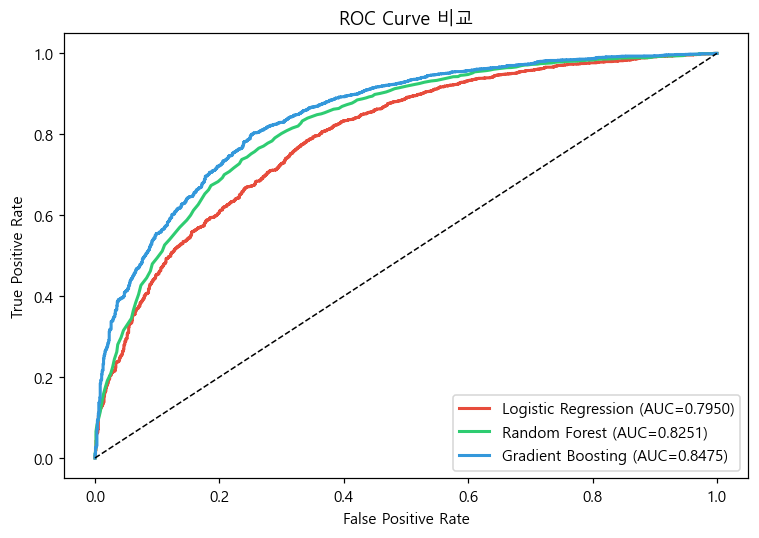

In [39]:
# ── 모델 성능 비교 표 + ROC Curve ───────────────────────
summary = pd.DataFrame({
    name: {
        'CV F1 (mean)': f'{r["cv_f1"]:.4f}',
        'CV F1 (std)':  f'{r["cv_f1_std"]:.4f}',
        'Accuracy':     f'{r["accuracy"]:.4f}',
        'Precision':    f'{r["precision"]:.4f}',
        'Recall':       f'{r["recall"]:.4f}',
        'F1':           f'{r["f1"]:.4f}',
        'AUC-ROC':      f'{r["auc"]:.4f}',
    }
    for name, r in results.items()
}).T
print(summary.to_string())

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={r["auc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve 비교')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

▶ 최고 성능 모델: Gradient Boosting  (AUC=0.8475)

              precision    recall  f1-score   support

       이탈(0)       0.72      0.54      0.62      1314
       잔존(1)       0.84      0.92      0.87      3313

    accuracy                           0.81      4627
   macro avg       0.78      0.73      0.75      4627
weighted avg       0.80      0.81      0.80      4627



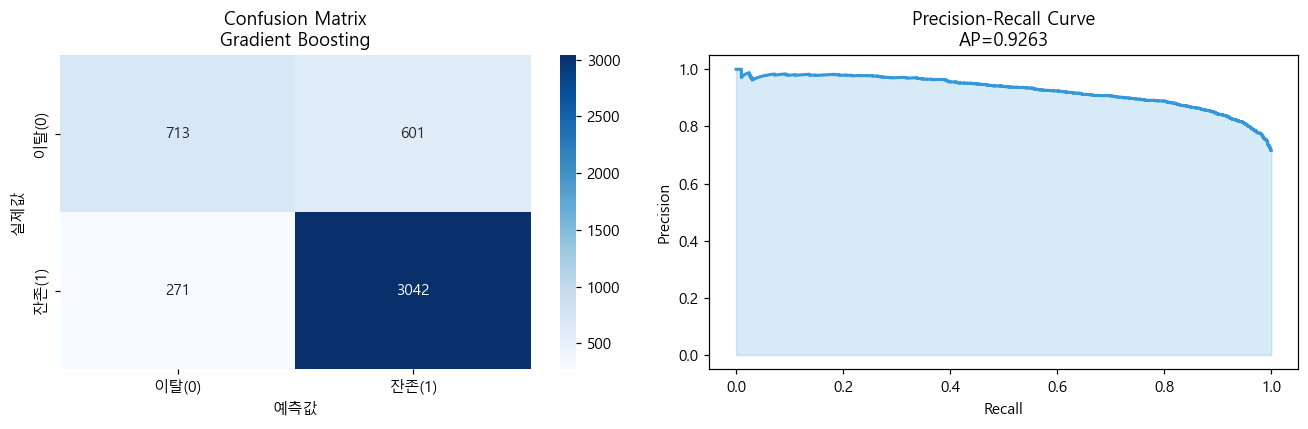

In [40]:
# ── 최고 성능 모델 상세 평가 ─────────────────────────────
best_name = max(results, key=lambda k: results[k]['auc'])
best      = results[best_name]
print(f'▶ 최고 성능 모델: {best_name}  (AUC={best["auc"]:.4f})\n')
print(classification_report(y_test, best['y_pred'], target_names=['이탈(0)', '잔존(1)']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['이탈(0)', '잔존(1)'], yticklabels=['이탈(0)', '잔존(1)'])
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('실제값')
axes[0].set_title(f'Confusion Matrix\n{best_name}')

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score
precision_arr, recall_arr, _ = precision_recall_curve(y_test, best['y_proba'])
ap = average_precision_score(y_test, best['y_proba'])
axes[1].plot(recall_arr, precision_arr, color='#3498db', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve\nAP={ap:.4f}')
axes[1].fill_between(recall_arr, precision_arr, alpha=0.2, color='#3498db')

plt.tight_layout()
plt.show()

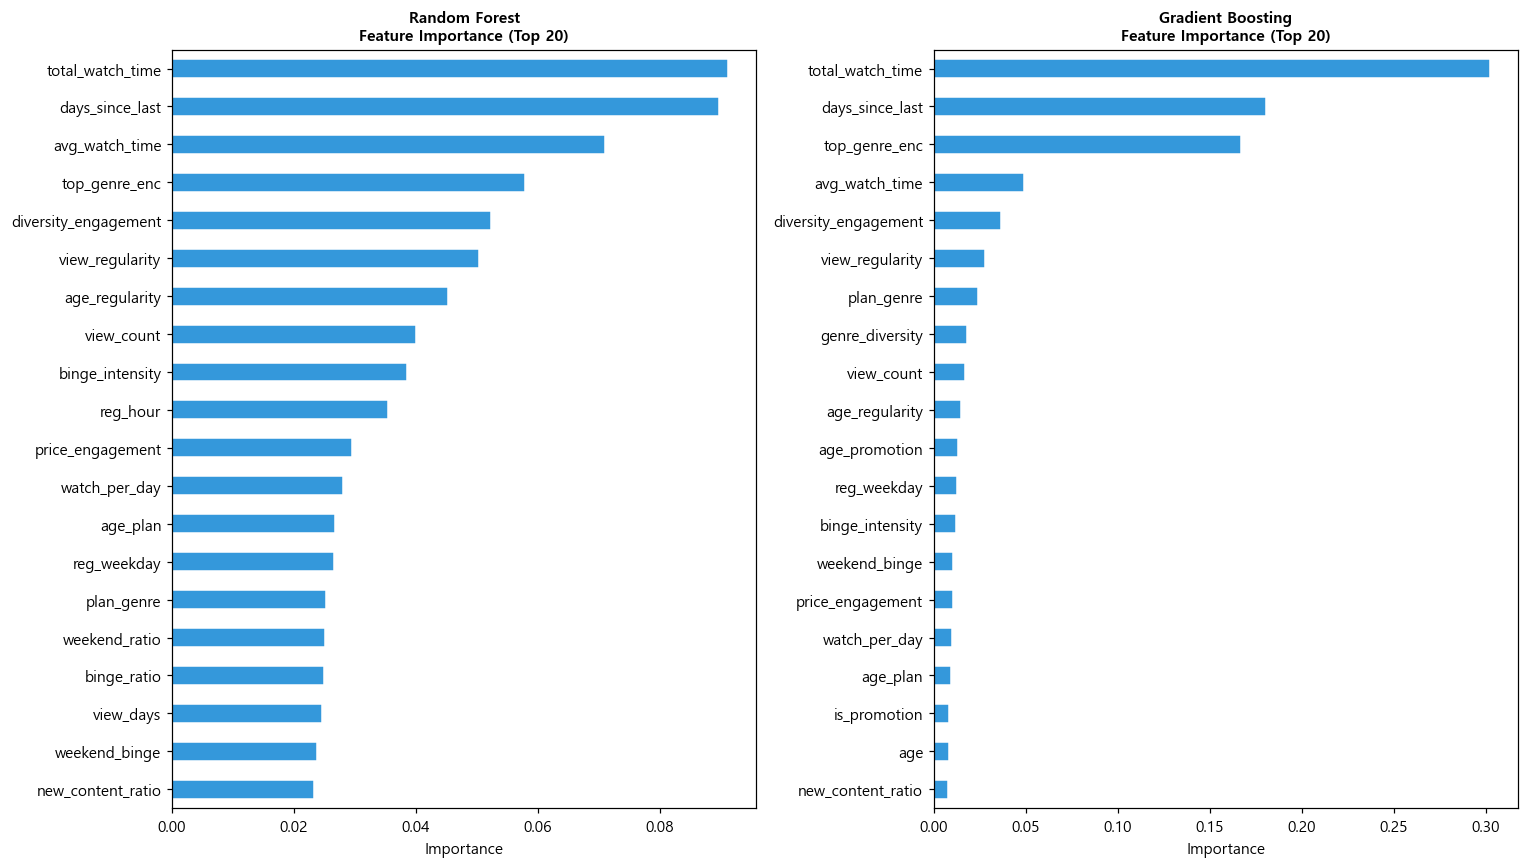

In [41]:
# ── Feature Importance (트리 기반 모델) ──────────────────
tree_models = {k: v for k, v in results.items() if k != 'Logistic Regression'}

fig, axes = plt.subplots(1, len(tree_models), figsize=(14, 8))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, tree_models.items()):
    imp = pd.Series(r['model'].feature_importances_, index=features)
    top20 = imp.sort_values(ascending=True).tail(20)
    top20.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'{name}\nFeature Importance (Top 20)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

|r| ≥ 0.7 피처 쌍 (10개):
  is_promotion                   ↔  verified_promotion              r=1.0
  reg_hour                       ↔  reg_time_enc                    r=0.972
  is_promotion                   ↔  age_promotion                   r=0.893
  age_promotion                  ↔  verified_promotion              r=0.893
  view_count                     ↔  diversity_engagement            r=0.87
  max_screen                     ↔  age_plan                        r=0.844
  view_count                     ↔  total_watch_time                r=0.782
  genre_diversity                ↔  diversity_engagement            r=0.737
  total_watch_time               ↔  is_heavy_user                   r=0.719
  total_watch_time               ↔  diversity_engagement            r=0.706


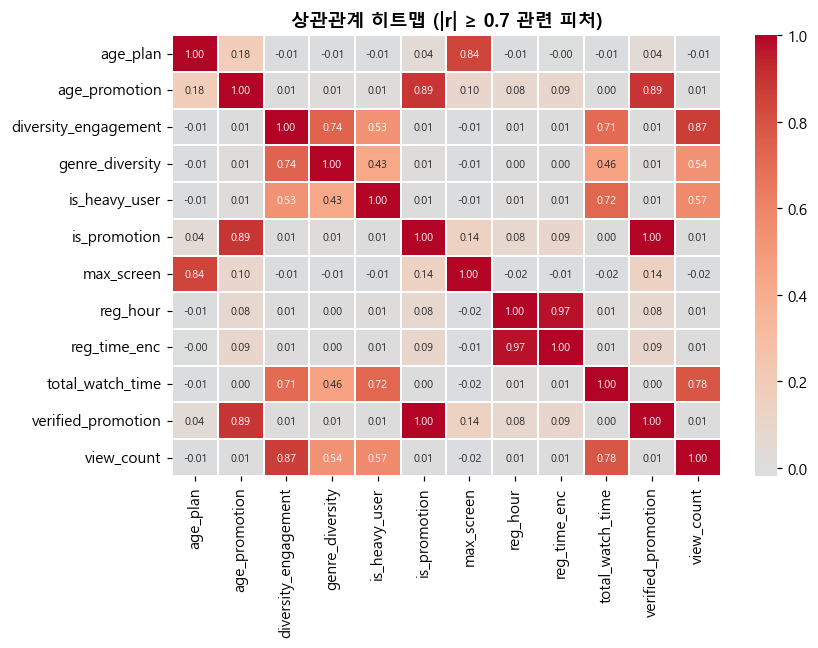

In [42]:
# ── 다중공선성 확인 ──────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ① 상관관계 히트맵 (|r| > 0.7 이상만 표시)
corr = X.corr()
high_corr_pairs = [(corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3))
                   for i in range(len(corr.columns))
                   for j in range(i+1, len(corr.columns))
                   if abs(corr.iloc[i, j]) >= 0.7]

print(f'|r| ≥ 0.7 피처 쌍 ({len(high_corr_pairs)}개):')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f'  {a:<30} ↔  {b:<30}  r={r}')

involved = set()
for a, b, _ in high_corr_pairs:
    involved.add(a); involved.add(b)
involved = sorted(involved)

if involved:
    fig, ax = plt.subplots(figsize=(max(8, len(involved)*0.6), max(6, len(involved)*0.5)))
    sns.heatmap(corr.loc[involved, involved], annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
    ax.set_title('상관관계 히트맵 (|r| ≥ 0.7 관련 피처)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('고상관 피처 쌍 없음')

VIF 전체 결과:
                     피처       VIF
     verified_promotion       inf
           is_promotion       inf
               reg_hour 79.249803
           reg_time_enc 65.866112
                    age 52.368487
             max_screen 36.231293
             view_count 31.542519
               age_plan 30.535008
        genre_diversity 27.460815
          age_promotion 23.390698
              view_days 16.102902
            binge_ratio 14.808211
   diversity_engagement 14.291130
         age_regularity 13.017965
             plan_genre 13.004718
       total_watch_time 10.848267
       is_user_verified  9.752193
        days_since_last  8.770990
        binge_intensity  8.493086
          watch_per_day  7.775503
         avg_watch_time  6.126711
        view_regularity  5.635350
          weekend_binge  5.573956
          weekend_ratio  5.353233
                  price  5.002138
          is_heavy_user  4.525372
            reg_weekday  3.631733
   fresh_content_engage  3.512328
   

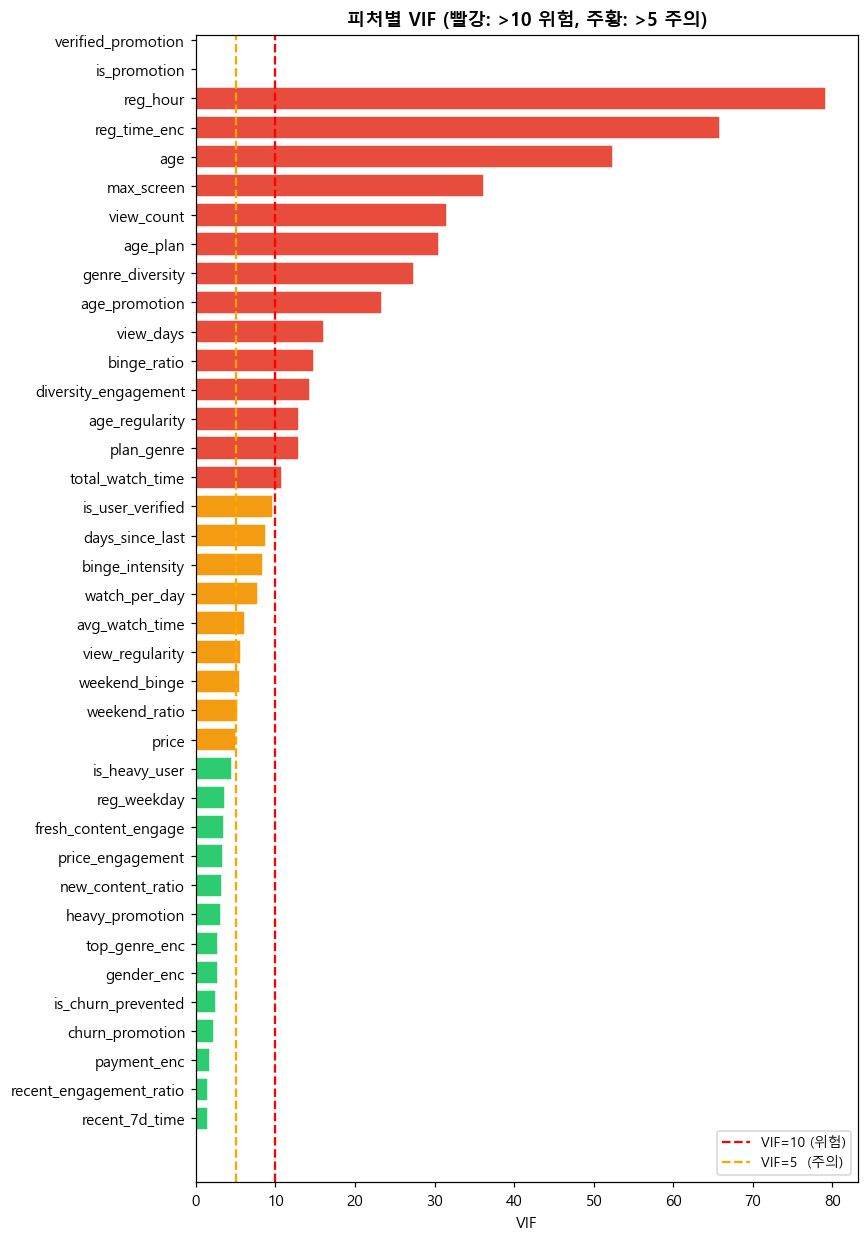

In [43]:
# ② VIF 계산
X_vif = X.copy().astype(float)

vif_data = pd.DataFrame({
    '피처':  X_vif.columns,
    'VIF':   [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF 전체 결과:')
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
print(f'\n⚠️  VIF > 10 (다중공선성 의심): {len(high_vif)}개')
print(high_vif.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(6, len(vif_data)*0.3)))
colors = ['#e74c3c' if v > 10 else ('#f39c12' if v > 5 else '#2ecc71')
          for v in vif_data['VIF']]
ax.barh(vif_data['피처'][::-1], vif_data['VIF'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=10, color='red',    linestyle='--', lw=1.5, label='VIF=10 (위험)')
ax.axvline(x=5,  color='orange', linestyle='--', lw=1.5, label='VIF=5  (주의)')
ax.set_xlabel('VIF')
ax.set_title('피처별 VIF (빨강: >10 위험, 주황: >5 주의)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [44]:
# ── 다중공선성 제거 후 재학습 ────────────────────────────
# 제거 이유:
#   is_heavy_user : total_watch_time의 이진화 → 완전 파생, 높은 상관/VIF
#   max_screen    : age_plan, plan_genre에 이미 곱 형태로 포함 → VIF 높음
#   reg_time_enc  : reg_hour 기반 구간화 → reg_hour와 중복

remove_cols = [
    'is_heavy_user',
    'max_screen',
    'reg_time_enc',
]

features_v2 = [f for f in features if f not in remove_cols]

X2 = df[features_v2].copy()
X2 = X2.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'피처 수: {len(features)} → {len(features_v2)}개')
print(f'제거된 변수: {remove_cols}')

# VIF 재확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
X2_vif = X2.copy().astype(float)
vif2 = pd.DataFrame({
    '피처': X2_vif.columns,
    'VIF':  [variance_inflation_factor(X2_vif.values, i) for i in range(X2_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('\nVIF 재계산 (상위 15개):')
print(vif2.head(15).to_string(index=False))
high_vif2 = vif2[vif2['VIF'] > 10]
print(f'\n⚠️  VIF > 10: {len(high_vif2)}개  (이전: {len(vif_data[vif_data["VIF"]>10])}개)')

피처 수: 38 → 35개
제거된 변수: ['is_heavy_user', 'max_screen', 'reg_time_enc']

VIF 재계산 (상위 15개):
                  피처       VIF
  verified_promotion       inf
        is_promotion       inf
                 age 47.452742
          view_count 31.326068
     genre_diversity 26.524060
       age_promotion 20.503819
           view_days 15.577015
         binge_ratio 14.712556
diversity_engagement 14.182338
      age_regularity 12.800203
            age_plan 11.011905
          plan_genre 10.613811
    total_watch_time 10.294462
    is_user_verified  9.474648
     days_since_last  8.400341

⚠️  VIF > 10: 13개  (이전: 16개)


모델                         이전 F1    이후 F1     이전 AUC    이후 AUC  변화
----------------------------------------------------------------------
Logistic Regression       0.7838   0.7839     0.7950    0.7948  F1▲0.0001 AUC▼0.0002
Random Forest             0.8677   0.8672     0.8251    0.8261  F1▼0.0005 AUC▲0.0010
Gradient Boosting         0.8746   0.8731     0.8475    0.8471  F1▼0.0016 AUC▼0.0004


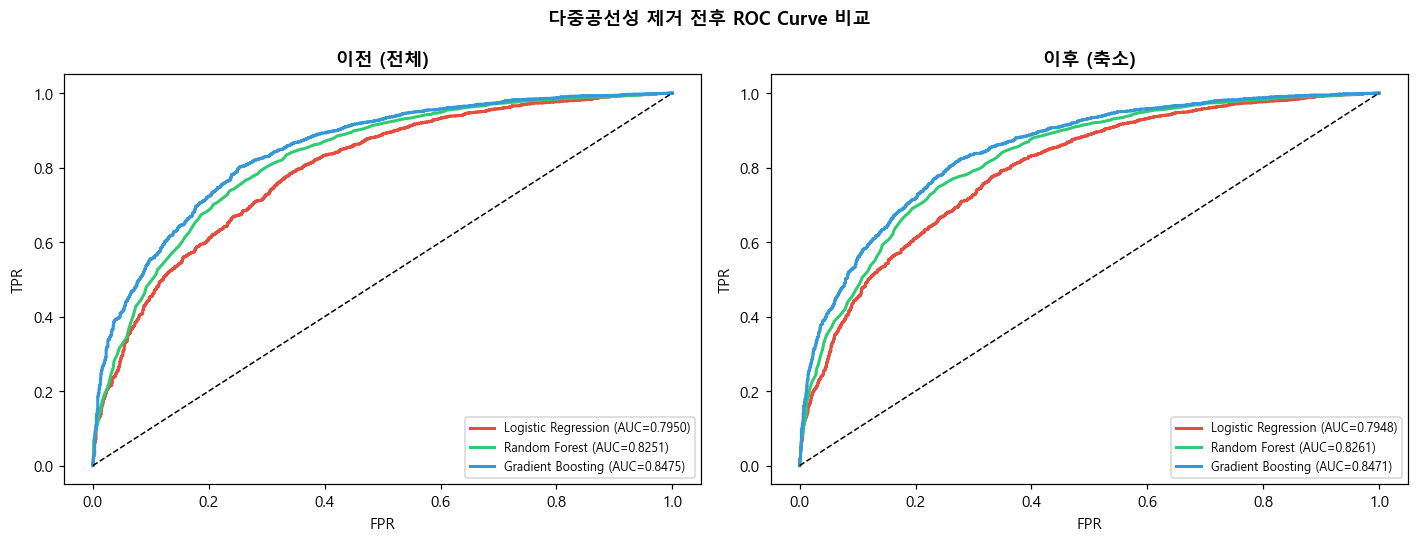

In [45]:
# ── 모델 재학습 & 성능 비교 ──────────────────────────────
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
scaler2     = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

results_v2 = {}
for name, _ in models.items():
    model2 = (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
              if name == 'Logistic Regression' else
              RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
              if name == 'Random Forest' else
              GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42))

    X_tr = X2_train_sc if name == 'Logistic Regression' else X2_train
    X_te = X2_test_sc  if name == 'Logistic Regression' else X2_test
    X_cv = X2_train_sc if name == 'Logistic Regression' else X2_train

    cv_f1 = cross_val_score(model2, X_cv, y2_train, cv=cv, scoring='f1')
    model2.fit(X_tr, y2_train)
    y_pred  = model2.predict(X_te)
    y_proba = model2.predict_proba(X_te)[:, 1]

    results_v2[name] = {
        'model': model2, 'y_pred': y_pred, 'y_proba': y_proba,
        'cv_f1': cv_f1.mean(), 'f1': f1_score(y2_test, y_pred),
        'auc':   roc_auc_score(y2_test, y_proba),
    }

# ── 전/후 비교표 ─────────────────────────────────────────
print(f'{"모델":<22}  {"이전 F1":>8} {"이후 F1":>8}  {"이전 AUC":>9} {"이후 AUC":>9}  변화')
print('-' * 70)
for name in models:
    b = results[name];  a = results_v2[name]
    df1 = a['f1']  - b['f1'];  da = a['auc'] - b['auc']
    arrow_f1  = '▲' if df1 > 0 else ('▼' if df1 < 0 else '─')
    arrow_auc = '▲' if da  > 0 else ('▼' if da  < 0 else '─')
    print(f'{name:<22}  {b["f1"]:>8.4f} {a["f1"]:>8.4f}  {b["auc"]:>9.4f} {a["auc"]:>9.4f}'
          f'  F1{arrow_f1}{abs(df1):.4f} AUC{arrow_auc}{abs(da):.4f}')

# ── ROC 비교 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for ax, (title, res) in zip(axes, [('이전 (전체)', results), ('이후 (축소)', results_v2)]):
    for (name, r), color in zip(res.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={r["auc"]:.4f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('다중공선성 제거 전후 ROC Curve 비교', fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# ── 최소 제거 버전 재학습 ─────────────────────────────────
# 트리 모델은 상관관계 높아도 예측 성능 영향 적음
# 수학적으로 완전히 동일한(r=1.0) 변수만 제거
# → 변수 재편 후 r=1.0 쌍은 상관관계 히트맵 결과에서 직접 확인

remove_exact = [col for col in [] if col in features]  # 히트맵 결과로 직접 채울 것

features_v3 = [f for f in features if f not in remove_exact]
X3 = df[features_v3].copy()
X3 = X3.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'피처 수: {len(features)} → {len(features_v3)}개 (r=1.0 완전 중복 {len(remove_exact)}개 제거)')

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42, stratify=y
)
scaler3     = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

results_v3 = {}
for name in models:
    model3 = (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
              if name == 'Logistic Regression' else
              RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
              if name == 'Random Forest' else
              GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42))

    X_tr = X3_train_sc if name == 'Logistic Regression' else X3_train
    X_te = X3_test_sc  if name == 'Logistic Regression' else X3_test

    cv_f1 = cross_val_score(model3, X_tr, y3_train, cv=cv, scoring='f1')
    model3.fit(X_tr, y3_train)
    y_pred  = model3.predict(X_te)
    y_proba = model3.predict_proba(X_te)[:, 1]

    results_v3[name] = {
        'model': model3, 'y_pred': y_pred, 'y_proba': y_proba,
        'cv_f1': cv_f1.mean(), 'f1': f1_score(y3_test, y_pred),
        'auc':   roc_auc_score(y3_test, y_proba),
    }

# ── 3가지 버전 비교표 ────────────────────────────────────
print(f'\n{"모델":<22}  {"전체 F1":>8} {"축소 F1":>8} {"최소 F1":>8}  {"전체 AUC":>9} {"축소 AUC":>9} {"최소 AUC":>9}')
print('-' * 85)
for name in models:
    r1 = results[name]; r2 = results_v2[name]; r3 = results_v3[name]
    print(f'{name:<22}  {r1["f1"]:>8.4f} {r2["f1"]:>8.4f} {r3["f1"]:>8.4f}'
          f'  {r1["auc"]:>9.4f} {r2["auc"]:>9.4f} {r3["auc"]:>9.4f}')

피처 수: 38 → 38개 (r=1.0 완전 중복 0개 제거)

모델                         전체 F1    축소 F1    최소 F1     전체 AUC    축소 AUC    최소 AUC
-------------------------------------------------------------------------------------
Logistic Regression       0.7838   0.7839   0.7838     0.7950    0.7948    0.7950
Random Forest             0.8677   0.8672   0.8677     0.8251    0.8261    0.8251
Gradient Boosting         0.8746   0.8731   0.8746     0.8475    0.8471    0.8475


✅ 실제 기여 변수 (32개):
                  변수   평균 중요도     표준편차
     days_since_last 0.078021 0.002678
       top_genre_enc 0.071831 0.003006
    total_watch_time 0.045798 0.002936
      avg_watch_time 0.013743 0.001984
     view_regularity 0.010387 0.001519
diversity_engagement 0.005388 0.001223
     genre_diversity 0.005094 0.001219
          plan_genre 0.003346 0.000829
       age_promotion 0.002596 0.000817
  is_churn_prevented 0.002323 0.000748
                 age 0.002210 0.000492
      age_regularity 0.002208 0.000712
         binge_ratio 0.002157 0.000373
       weekend_binge 0.002129 0.000309
         reg_weekday 0.002057 0.000764
        is_promotion 0.001969 0.000573
   new_content_ratio 0.001853 0.000415
  verified_promotion 0.001801 0.000549
       weekend_ratio 0.001702 0.000592
           view_days 0.001271 0.000461
     churn_promotion 0.000906 0.000389
    price_engagement 0.000699 0.000511
fresh_content_engage 0.000166 0.000288
          max_screen 0.000106 0.000124
       

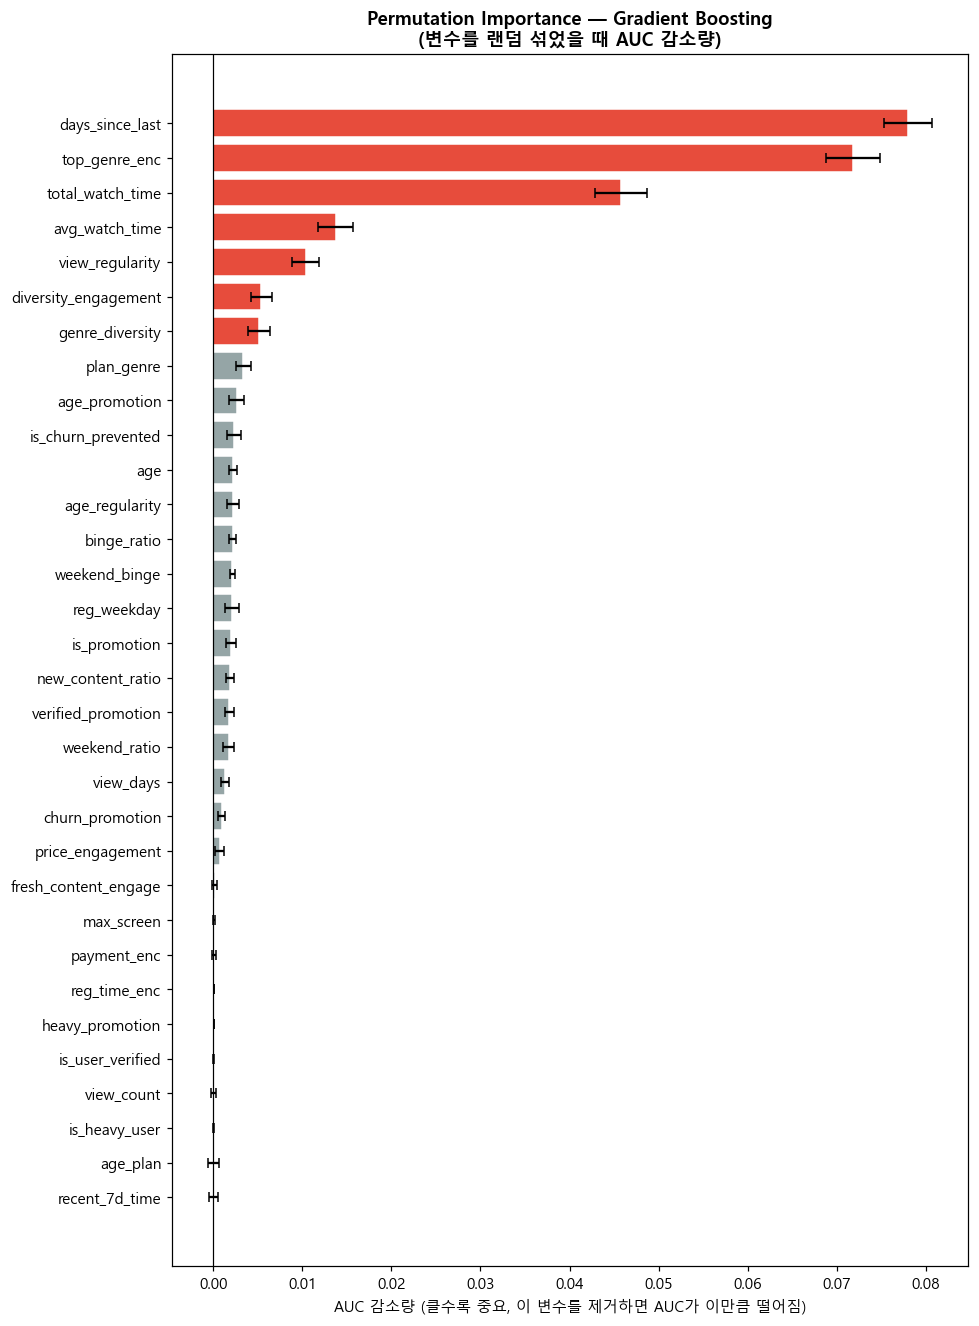

In [47]:
from sklearn.inspection import permutation_importance

# Gradient Boosting 기준 Permutation Importance
gbt = results['Gradient Boosting']['model']
perm = permutation_importance(gbt, X_test, y_test,
                               n_repeats=10, random_state=42,
                               scoring='roc_auc')

perm_df = pd.DataFrame({
    '변수':       features,
    '평균 중요도': perm.importances_mean,
    '표준편차':   perm.importances_std,
}).sort_values('평균 중요도', ascending=False).reset_index(drop=True)

# 양수(실제 기여) vs 무의미 변수 분리
pos_df = perm_df[perm_df['평균 중요도'] > 0]
neg_df = perm_df[perm_df['평균 중요도'] <= 0]

print(f'✅ 실제 기여 변수 ({len(pos_df)}개):')
print(pos_df.to_string(index=False))
print(f'\n❌ 기여 없는 변수 ({len(neg_df)}개): {neg_df["변수"].tolist()}')

# ── 시각화 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(6, len(pos_df) * 0.38)))
colors = ['#e74c3c' if v > 0.005 else '#95a5a6' for v in pos_df['평균 중요도']]
ax.barh(pos_df['변수'][::-1], pos_df['평균 중요도'][::-1],
        xerr=pos_df['표준편차'][::-1],
        color=colors[::-1], edgecolor='white', capsize=3)
ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlabel('AUC 감소량 (클수록 중요, 이 변수를 제거하면 AUC가 이만큼 떨어짐)')
ax.set_title('Permutation Importance — Gradient Boosting\n(변수를 랜덤 섞었을 때 AUC 감소량)',
             fontweight='bold')
plt.tight_layout()
plt.show()